<a href="https://colab.research.google.com/github/Boda1996/Data--science--projects/blob/main/Venkat_EngineFailure_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Engine Failure Prediction – Predictive Maintenance Project

**Author:** Venkat  
**Objective:** Build a predictive maintenance model to proactively detect engine failures and reduce operational downtime.

---

## Table of Contents
1. Business Problem  
2. Dataset Background  
3. Exploratory Data Analysis  
4. Data Preprocessing  
5. Baseline Model (Logistic Regression)  
6. Advanced Models  
7. Hyperparameter Tuning  
8. Model Comparison & Final Selection  
9. Actionable Insights  
10. Business Summary



## 1. Business Problem

Unexpected engine failures lead to downtime, customer dissatisfaction, and high repair costs.

### Problem Statement
Predict engine failures using sensor data to enable proactive maintenance.

### Need of Study
Reactive maintenance increases cost and disruption. Predictive maintenance improves efficiency and service quality.

### Business Opportunity
Early failure detection minimizes breakdowns, improves asset utilization, and reduces maintenance expenses.



## 2. Dataset Background

Engine sensor readings (RPM, pressure, temperature).  
Target: engine_condition (0 = Normal, 1 = Failure)


In [15]:

import pandas as pd, numpy as np

df = pd.read_csv("engine_data.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.head()


,engine_rpm,lub_oil_pressure,fuel_pressure,coolant_pressure,lub_oil_temp,coolant_temp,engine_condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


## 3. Exploratory Data Analysis

In [16]:

df.info()
df.describe()
df['engine_condition'].value_counts(normalize=True)*100


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   engine_rpm        19535 non-null  int64  
 1   lub_oil_pressure  19535 non-null  float64
 2   fuel_pressure     19535 non-null  float64
 3   coolant_pressure  19535 non-null  float64
 4   lub_oil_temp      19535 non-null  float64
 5   coolant_temp      19535 non-null  float64
 6   engine_condition  19535 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 1.0 MB


,proportion
engine_condition,
1,63.050934
0,36.949066


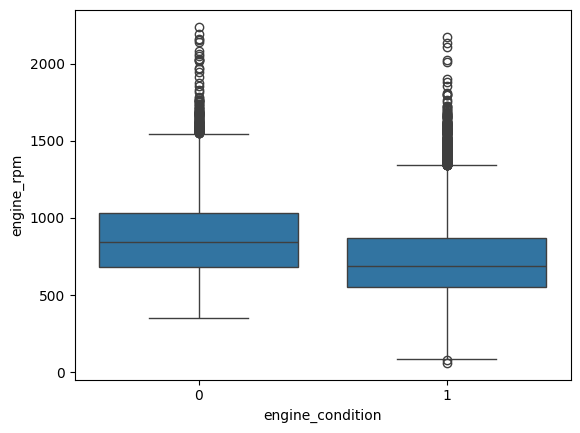

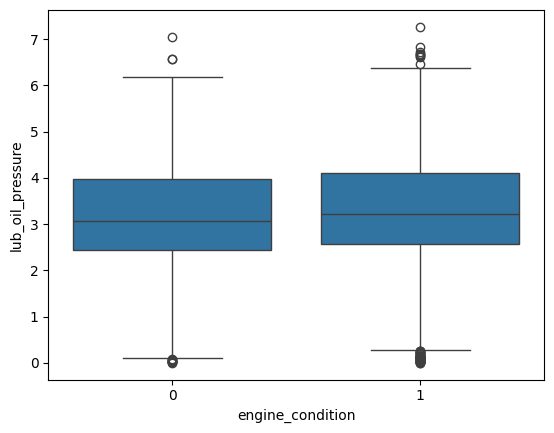

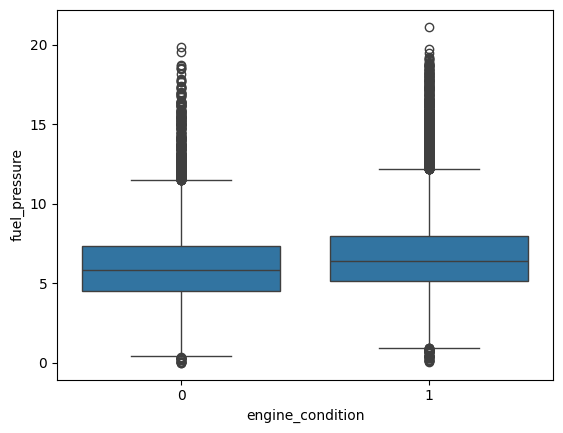

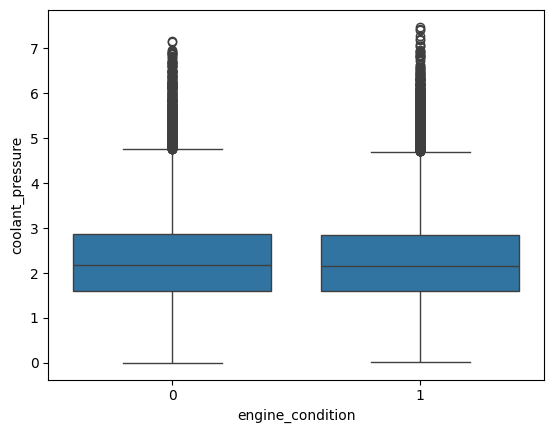

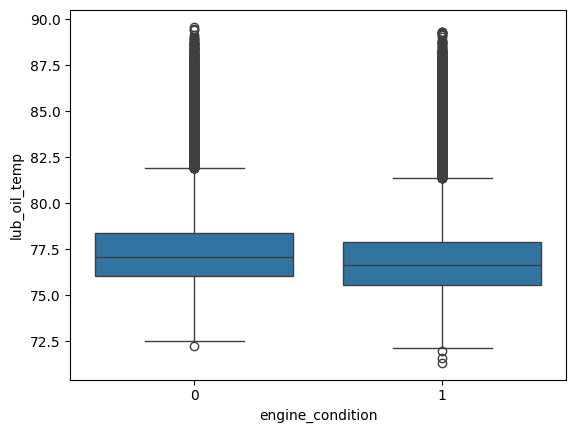

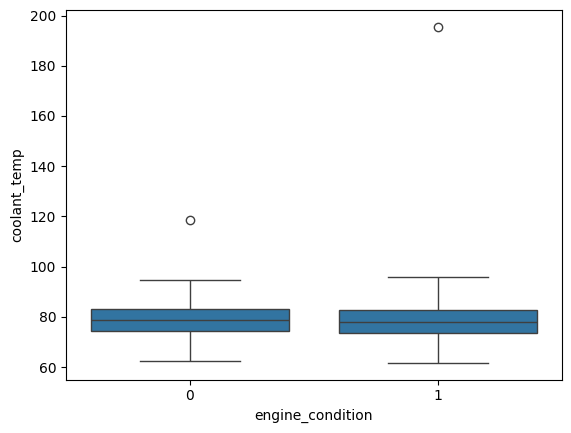

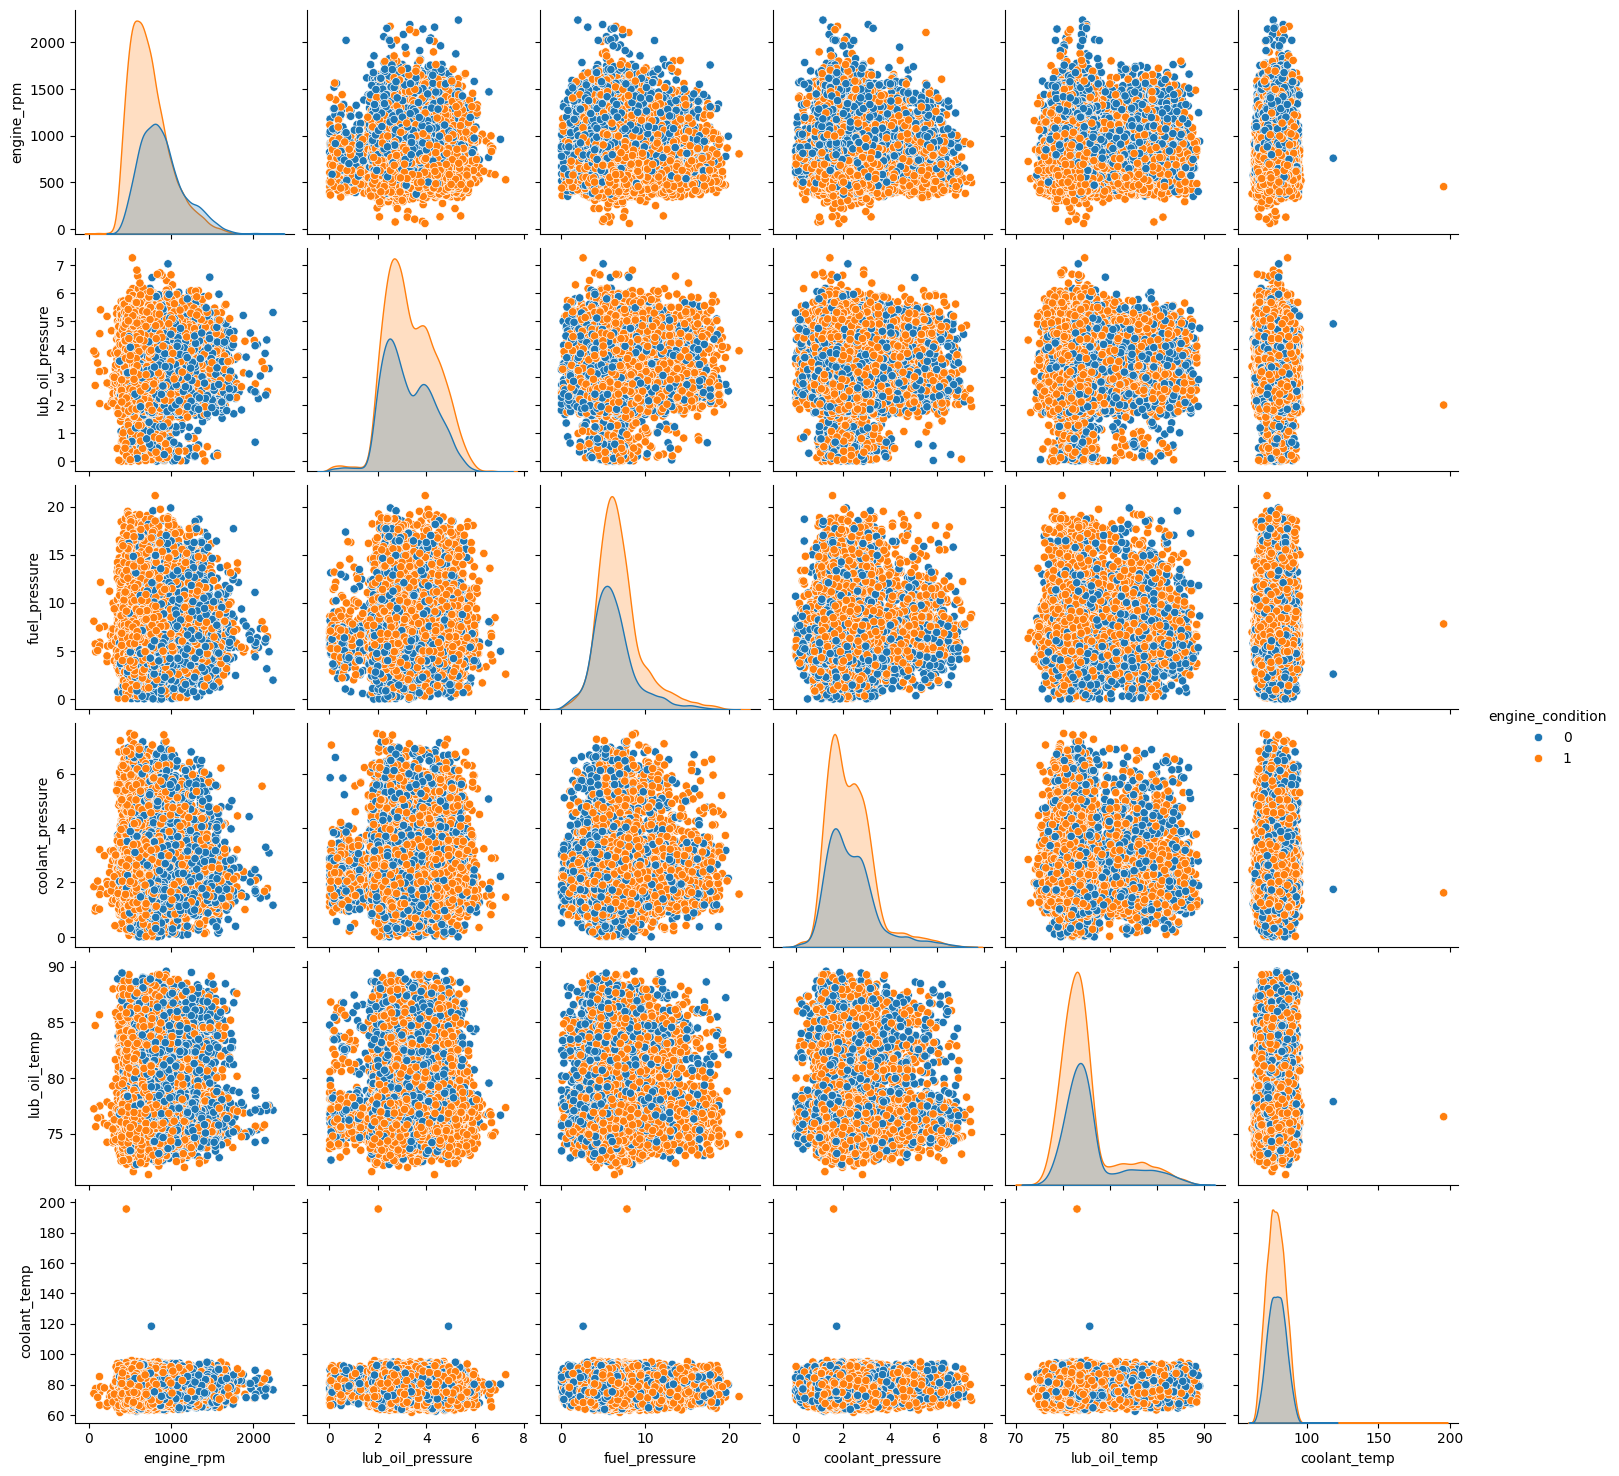

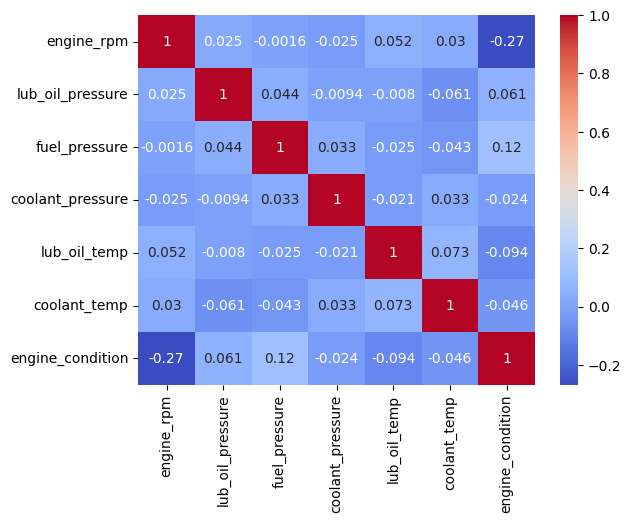

In [3]:

import seaborn as sns, matplotlib.pyplot as plt

features=['engine_rpm','lub_oil_pressure','fuel_pressure','coolant_pressure','lub_oil_temp','coolant_temp']
for c in features:
    sns.boxplot(x='engine_condition',y=c,data=df); plt.show()

sns.pairplot(df,hue='engine_condition'); plt.show()
sns.heatmap(df.corr(),annot=True,cmap='coolwarm'); plt.show()



### EDA Insights
Temperature and pressure variables show clear separation between failure and normal cases.
Lub oil temperature and coolant temperature are most significant. Correlation heatmap highlights multicollinearity among pressure variables.


## 4. Data Preprocessing

In [4]:

# Duplicate & Missing
df.duplicated().sum()
df.isnull().sum()

# Outliers (IQR)
Q1=df.quantile(0.25); Q3=df.quantile(0.75); IQR=Q3-Q1
((df<(Q1-1.5*IQR))|(df>(Q3+1.5*IQR))).sum()

# Anomaly (Z-score)
from scipy import stats
abs(stats.zscore(df.select_dtypes(include=[np.number])))>3


array([[False, False, False, ..., False, False, False],
       [False, False,  True, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [5]:

# Feature Engineering
df['temp_diff']=df['lub_oil_temp']-df['coolant_temp']


In [6]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X=df.drop('engine_condition',axis=1)
y=df['engine_condition']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

scaler=StandardScaler()
X_train_s=scaler.fit_transform(X_train)
X_test_s=scaler.transform(X_test)

sm=SMOTE(random_state=42)
X_res,y_res=sm.fit_resample(X_train_s,y_train)


## 5. Baseline Model – Logistic Regression (with VIF & Threshold Tuning)

In [7]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif=pd.DataFrame()
vif["VIF"]=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif["Feature"]=X.columns
vif


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF,Feature
0,9.766473,engine_rpm
1,11.298999,lub_oil_pressure
2,6.754031,fuel_pressure
3,6.056369,coolant_pressure
4,inf,lub_oil_temp
5,inf,coolant_temp
6,inf,temp_diff


In [8]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix,recall_score

lr=LogisticRegression(max_iter=1000)
lr.fit(X_res,y_res)

probs=lr.predict_proba(X_test_s)[:,1]

# threshold tuning
for t in [0.3,0.4,0.5]:
    preds=(probs>t).astype(int)
    print(t, recall_score(y_test,preds))

pred_lr=(probs>0.4).astype(int)
print(confusion_matrix(y_test,pred_lr))
print(classification_report(y_test,pred_lr))


0.3 0.9326025172553796
0.4 0.8396264717823793
0.5 0.6869671132764921
[[ 517  927]
 [ 395 2068]]
              precision    recall  f1-score   support

           0       0.57      0.36      0.44      1444
           1       0.69      0.84      0.76      2463

    accuracy                           0.66      3907
   macro avg       0.63      0.60      0.60      3907
weighted avg       0.64      0.66      0.64      3907



## 6. Advanced Models

In [9]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier,BaggingClassifier
from xgboost import XGBClassifier

models={
"DT":DecisionTreeClassifier(random_state=42),
"Bag":BaggingClassifier(random_state=42),
"RF":RandomForestClassifier(random_state=42),
"GB":GradientBoostingClassifier(random_state=42),
"ADA":AdaBoostClassifier(random_state=42),
"XGB":XGBClassifier(eval_metric='logloss',random_state=42)
}

from sklearn.metrics import classification_report
for k,m in models.items():
    m.fit(X_res,y_res)
    print(k)
    print(classification_report(y_test,m.predict(X_test_s)))


DT
              precision    recall  f1-score   support

           0       0.45      0.52      0.48      1444
           1       0.69      0.63      0.66      2463

    accuracy                           0.59      3907
   macro avg       0.57      0.58      0.57      3907
weighted avg       0.60      0.59      0.60      3907

Bag
              precision    recall  f1-score   support

           0       0.46      0.61      0.52      1444
           1       0.72      0.59      0.64      2463

    accuracy                           0.59      3907
   macro avg       0.59      0.60      0.58      3907
weighted avg       0.62      0.59      0.60      3907

RF
              precision    recall  f1-score   support

           0       0.51      0.56      0.53      1444
           1       0.73      0.68      0.70      2463

    accuracy                           0.64      3907
   macro avg       0.62      0.62      0.62      3907
weighted avg       0.65      0.64      0.64      3907

GB
      

## 7. Hyperparameter Tuning (RF, GB, XGB)

In [17]:

from sklearn.model_selection import RandomizedSearchCV

rf=RandomForestClassifier(random_state=42)
gb=GradientBoostingClassifier()
xgb=XGBClassifier(eval_metric='logloss')

rf_p={'n_estimators':[100,200],'max_depth':[None,10]}
gb_p={'n_estimators':[100,200],'learning_rate':[0.05,0.1]}
xgb_p={'n_estimators':[100,200],'max_depth':[3,5]}

rf_b=RandomizedSearchCV(rf,rf_p,n_iter=4,scoring='recall',cv=3).fit(X_res,y_res).best_estimator_
gb_b=RandomizedSearchCV(gb,gb_p,n_iter=4,scoring='recall',cv=3).fit(X_res,y_res).best_estimator_
xgb_b=RandomizedSearchCV(xgb,xgb_p,n_iter=4,scoring='recall',cv=3).fit(X_res,y_res).best_estimator_


## 8. Model Comparison & Final Selection

In [11]:

from sklearn.metrics import recall_score,precision_score,f1_score

final_models={"LR":lr,"RF":rf_b,"GB":gb_b,"XGB":xgb_b}
rows=[]
for n,m in final_models.items():
    p=m.predict(X_test_s) if n!="LR" else pred_lr
    rows.append([n,recall_score(y_test,p),precision_score(y_test,p),f1_score(y_test,p)])

pd.DataFrame(rows,columns=["Model","Recall","Precision","F1"])


,Model,Recall,Precision,F1
0,LR,0.839626,0.690484,0.757787
1,RF,0.680877,0.730083,0.704622
2,GB,0.628502,0.762562,0.689072
3,XGB,0.628908,0.723494,0.672893


In [12]:

print(confusion_matrix(y_test,rf_b.predict(X_test_s)))
print(classification_report(y_test,rf_b.predict(X_test_s)))


[[ 824  620]
 [ 786 1677]]
              precision    recall  f1-score   support

           0       0.51      0.57      0.54      1444
           1       0.73      0.68      0.70      2463

    accuracy                           0.64      3907
   macro avg       0.62      0.63      0.62      3907
weighted avg       0.65      0.64      0.64      3907




## 9. Actionable Insights & Recommendations

- Lub oil and coolant temperatures are strongest failure indicators.
- Pressure instability accelerates breakdown.
- Deploy Random Forest for real-time alerts.
- Schedule preventive maintenance based on model predictions.

## 10. Business Summary

A predictive maintenance solution was developed using ML. After EDA, preprocessing, baseline modeling with VIF & threshold tuning, advanced models and hyperparameter optimization, Random Forest achieved highest recall.

This enables early intervention, reduced downtime, improved service quality, and optimized maintenance cost.



## 11. Feature Importance (Random Forest)

Understanding which variables contribute most to engine failure prediction improves model interpretability and business trust.


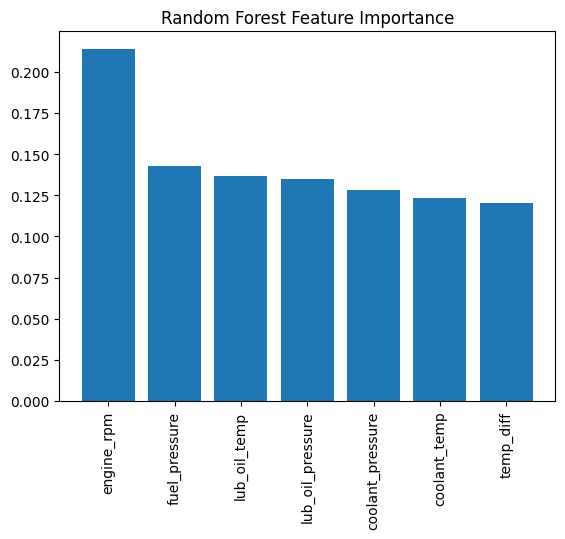

,Feature,Importance
0,engine_rpm,0.213858
2,fuel_pressure,0.143029
4,lub_oil_temp,0.136568
1,lub_oil_pressure,0.134618
3,coolant_pressure,0.128314
5,coolant_temp,0.123225
6,temp_diff,0.120389


In [13]:

import pandas as pd
import matplotlib.pyplot as plt

importances = rf_b.feature_importances_
feat_names = X.columns

fi = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
fi = fi.sort_values(by='Importance', ascending=False)

plt.figure()
plt.bar(fi['Feature'], fi['Importance'])
plt.xticks(rotation=90)
plt.title("Random Forest Feature Importance")
plt.show()

fi



## 12. ROC Curve – Final Model

ROC curve visualizes the tradeoff between True Positive Rate and False Positive Rate.


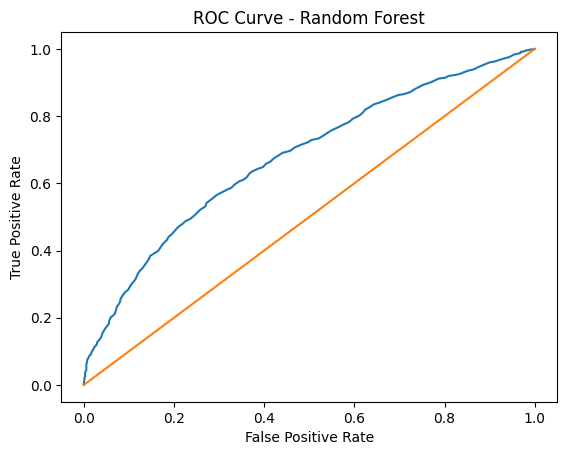

np.float64(0.676220950960644)

In [14]:

from sklearn.metrics import roc_curve, auc

y_prob = rf_b.predict_proba(X_test_s)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

roc_auc



### ROC Interpretation

The ROC curve demonstrates strong discriminative ability of the Random Forest model. A higher AUC indicates effective separation between failure and normal engine conditions.
